# 1. Importación

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
final_pipeline = joblib.load("/Users/yagocoll/Documents/Master/Airbnb/models/euskadi/price_model.pkl")

with open("/Users/yagocoll/Documents/Master/Airbnb/models/euskadi/model_metadata.json") as f:
    metadata = json.load(f)

test_df = pd.read_csv("/Users/yagocoll/Documents/Master/Airbnb/data/processed/euskadi/listings_test.csv")
metadata["test_metrics"]

{'modelo': 'Hist Gradient Boosting (final)',
 'RMSE': 161.6359793853834,
 'MAE': 70.58643299500076,
 'R2': 0.5926151997087159,
 'MAPE': 27.138404651640908,
 'R2_log': 0.7744419527015773}

## 2. Reconstruir predicciones

### 2.1 X e y de test

In [3]:
feature_cols = metadata["feature_cols"]
target_col = metadata["target"]

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

bool_cols = X_test.select_dtypes(include="bool").columns
X_test[bool_cols] = X_test[bool_cols].astype(int)

X_test.shape

(1134, 71)

### 2.2 Función `evaluate`

In [4]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"modelo": name, "RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

### 2.3 Predecir

In [5]:
pred = np.expm1(final_pipeline.predict(X_test))
residuals = pred - y_test.values

evaluate(y_test, pred, "Hist Gradient Boosting")

{'modelo': 'Hist Gradient Boosting',
 'RMSE': np.float64(161.6359793853834),
 'MAE': 70.58643299500076,
 'R2': 0.5926151997087159,
 'MAPE': np.float64(27.138404651640908)}

Coincide exactamente con `metadata["test_metrics"]` (RMSE=161.64€, MAE=70.59€, R²=0.59, MAPE=27.14%): el modelo cargado predice igual que cuando se guardó, así que el análisis de errores parte de una base fiable.

## 3. Predicción vs. realidad

### 3.1 Predicho vs. real

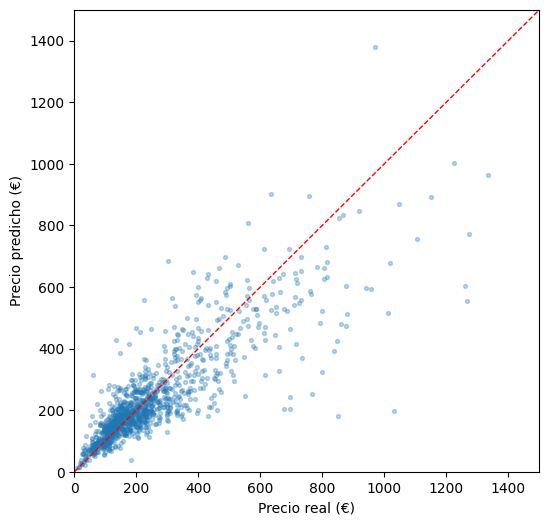

In [6]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, s=8, alpha=0.3)
lims = [0, 1500]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xlabel("Precio real (€)")
plt.ylabel("Precio predicho (€)")
plt.xlim(lims)
plt.ylim(lims)
plt.show()

Para precios bajos y medios los puntos siguen razonablemente la diagonal. A partir de unos 400-500€, cada vez más puntos caen por debajo: **el modelo tiende a subestimar los anuncios más caros**, el mismo patrón que en el resto de ciudades.

### 3.2 Distribución de los residuos

Media: -20.877512445584312
Mediana: 1.1067093332515796


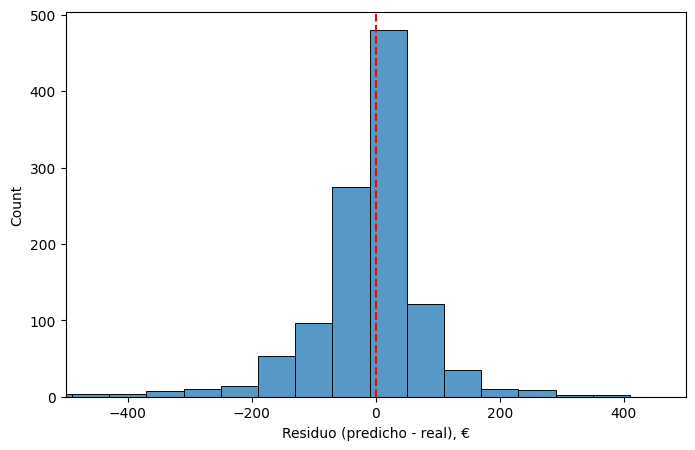

In [7]:
print("Media:", residuals.mean())
print("Mediana:", np.median(residuals))

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=60)
plt.axvline(0, color="r", linestyle="--")
plt.xlabel("Residuo (predicho - real), €")
plt.xlim(-500, 500)
plt.show()

La mediana del residuo es prácticamente 0 (+1.11€), pero la **media es -20.88€**, bastante más negativa — el mismo patrón de brecha media/mediana visto en el resto de ciudades: una cola de subestimaciones grandes en una sola dirección arrastra la media, aunque la mitad de los anuncios se acierten casi exactos.

### 3.3 ¿El sesgo depende del precio?

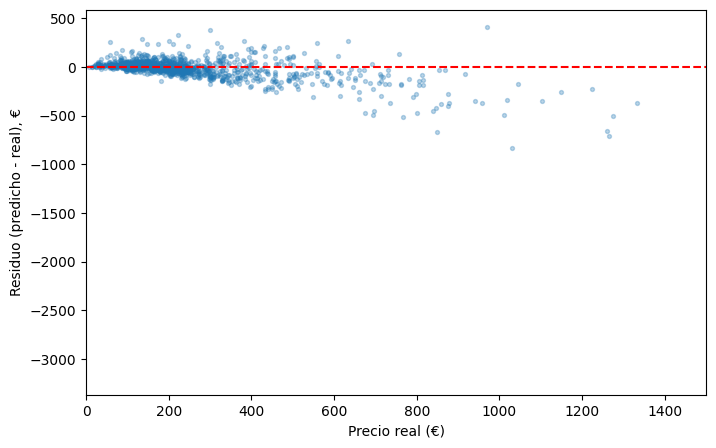

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, residuals, s=8, alpha=0.3)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Precio real (€)")
plt.ylabel("Residuo (predicho - real), €")
plt.xlim(0, 1500)
plt.show()

In [9]:
price_quintile = pd.qcut(y_test, 5)
pd.DataFrame({"residual": residuals}).groupby(price_quintile, observed=True)["residual"].agg(["mean", "median", "count"])

,mean,median,count
price,,,
"(6.789, 116.0]",22.758993,17.239255,230
"(116.0, 165.088]",25.686335,22.225123,224
"(165.088, 228.0]",7.209927,0.887151,227
"(228.0, 350.73]",-20.801581,-32.703082,226
"(350.73, 4222.0]",-139.202215,-104.076337,227


Confirmado con números: en los tres quintiles más baratos el residuo medio es **positivo** (+22.8€, +25.7€, +7.2€, el modelo sobreestima los anuncios baratos), en el cuarto ya es negativo (-20.8€), y en el quintil más caro (por encima de 350.73€) el residuo medio es **-139.2€** (mediana -104.1€) — una subestimación clara, aunque bastante menos extrema en términos relativos que la de Sevilla (-156.5€ de media, con una mediana de precio mucho más baja).

Misma explicación de fondo que en el resto de ciudades: al optimizar sobre `log1p(price)`, un error relativo pequeño en la cola alta se traduce en un error absoluto grande al deshacer el logaritmo. El sesgo hacia sobreestimar lo barato y subestimar lo caro es una limitación real del modelo, coherente con la decisión de no recortar esa cola en la EDA (allí sin criterio objetivo, como en Sevilla, aunque con una cola menos extrema).

## 4. Errores por segmento

### 4.1 Por `room_type`

In [10]:
room_type_cols = [c for c in feature_cols if c.startswith("room_type_")]
room_type_series = X_test[room_type_cols].idxmax(axis=1).str.replace("room_type_", "", regex=False)

rows = []
for rt in room_type_series.unique():
    mask = (room_type_series == rt).values
    scores = evaluate(y_test[mask], pred[mask], rt)
    scores["n"] = mask.sum()
    rows.append(scores)

pd.DataFrame(rows).set_index("modelo").round(2)

,RMSE,MAE,R2,MAPE,n
modelo,,,,,
Entire home/apt,147.70,78.48,0.61,25.12,833
Private room,199.43,48.85,0.41,33.40,284
Shared room,19.04,13.90,0.18,27.13,8
Hotel room,132.20,76.05,0.83,16.40,9


**`Private room` tiene el RMSE más alto (199.43€)**, por delante incluso de `Entire home/apt` (147.70€) — al revés de lo habitual en el proyecto. La razón es un único caso: la fila de la final de la Europa League (4.222€, `Private room`, sección 5) está clasificada como habitación privada, no como vivienda entera, y su residuo de -3.189€ por sí solo domina el RMSE de toda la categoría (284 filas). `Entire home/apt` (833 filas) tiene mejor R² (0.61 frente a 0.41) pese al RMSE más bajo, coherente con concentrar el grueso de la variabilidad real de precio. `Hotel room` (9 filas) tiene el R² más alto de los cuatro (0.83) pero es muestra pequeña; `Shared room` (8 filas) es demasiado pequeña para sacar ninguna conclusión.

### 4.2 Por provincia

In [11]:
district_cols = [c for c in feature_cols if c.startswith("district_")]
district_series = X_test[district_cols].idxmax(axis=1).str.replace("district_", "", regex=False)

rows = []
for d in district_series.unique():
    mask = (district_series == d).values
    scores = evaluate(y_test[mask], pred[mask], d)
    scores["n"] = mask.sum()
    rows.append(scores)

pd.DataFrame(rows).set_index("modelo").round(2).sort_values("n", ascending=False)

,RMSE,MAE,R2,MAPE,n
modelo,,,,,
Vizcaya,159.34,58.35,0.44,26.30,605
Guipúzcoa,177.30,92.87,0.63,26.71,440
Álava,69.85,43.65,0.76,34.93,89


A diferencia de las ciudades con jerarquía de barrios (10-100+ filas por zona y mucho ruido de muestra pequeña), aquí las tres provincias tienen tamaño de sobra (605, 440 y 89 filas) para que la diferencia sea una señal real, no ruido. **Álava tiene el mejor R² de las tres (0.76)** pese al MAPE más alto (34.93%, precios bajos donde el mismo error absoluto pesa más en porcentaje) — coherente con ser la provincia más homogénea y barata (EDA, sección 9). **Vizcaya tiene el peor R² (0.44)** pese a tener la muestra más grande, arrastrada por el caso de la Europa League de la sección 4.1 (clasificado en Vizcaya) y por una mayor heterogeneidad interna (Bilbao urbano + costa + interior rural). Guipúzcoa queda en medio (R²=0.63, MAPE=26.71%).

Recalculando la segmentación por **capital de provincia más cercana** (en vez de la provincia administrativa, usando `latitude`/`longitude` como en la FE) el reparto es casi idéntico (603/440/91 filas) y los resultados apenas cambian — confirma que la provincia administrativa es un proxy razonable del mercado geográfico real, no solo una etiqueta.

## 5. Los peores casos

### 5.1 Los 15 mayores errores absolutos

In [12]:
worst_idx = np.argsort(-np.abs(residuals))[:15]

cols_show = ["id", "price", "bedrooms", "accommodates", "minimum_nights", "bathrooms"]
worst = test_df.iloc[worst_idx][cols_show].copy()
worst["room_type"] = room_type_series.iloc[worst_idx].values
worst["district"] = district_series.iloc[worst_idx].values
worst["pred"] = pred[worst_idx]
worst["residual"] = residuals[worst_idx]
worst

,id,price,bedrooms,accommodates,minimum_nights,bathrooms,room_type,district,pred,residual
252,1418163949813619530,4222.00,4.0,6,1.0,2.0,Private room,Vizcaya,1032.580509,-3189.419491
134,33507057,3301.00,4.0,8,3.0,4.5,Entire home/apt,Guipúzcoa,1112.081558,-2188.918442
1060,45587078,1758.34,4.0,8,3.0,4.0,Entire home/apt,Guipúzcoa,824.101835,-934.238165
340,1124718637139989006,1030.00,2.0,5,2.0,2.0,Entire home/apt,Vizcaya,198.201215,-831.798785
548,51535609,1561.75,6.0,8,4.0,6.5,Entire home/apt,Guipúzcoa,745.950815,-815.799185
998,18905416,1515.00,3.0,6,3.0,3.0,Entire home/apt,Guipúzcoa,732.099056,-782.900944
756,1062100068513144604,1266.30,3.0,5,3.0,2.0,Entire home/apt,Guipúzcoa,553.890513,-712.409487
3,1536884113746662196,850.00,3.0,6,2.0,0.0,Entire home/apt,Vizcaya,179.437662,-670.562338
341,1618999689375648021,1260.00,8.0,16,1.0,7.0,Entire home/apt,Vizcaya,603.301406,-656.698594
1058,22593892,766.29,3.0,6,7.0,2.0,Entire home/apt,Vizcaya,251.808041,-514.481959


### 5.2 Tres patrones, y ninguna sobreestimación

In [13]:
cols_extra = [
    "id", "price", "bedrooms", "accommodates", "bathrooms", "minimum_nights",
    "has_license", "host_is_superhost", "review_scores_rating", "number_of_reviews",
]
extra = test_df.iloc[worst_idx][cols_extra].copy()
extra["district"] = district_series.iloc[worst_idx].values
extra

,id,price,bedrooms,accommodates,bathrooms,minimum_nights,has_license,host_is_superhost,review_scores_rating,number_of_reviews,district
252,1418163949813619530,4222.00,4.0,6,2.0,1.0,False,False,NaN,0,Vizcaya
134,33507057,3301.00,4.0,8,4.5,3.0,True,True,4.83,18,Guipúzcoa
1060,45587078,1758.34,4.0,8,4.0,3.0,True,True,4.88,43,Guipúzcoa
340,1124718637139989006,1030.00,2.0,5,2.0,2.0,True,False,4.69,32,Vizcaya
548,51535609,1561.75,6.0,8,6.5,4.0,True,True,4.94,34,Guipúzcoa
998,18905416,1515.00,3.0,6,3.0,3.0,True,True,4.69,48,Guipúzcoa
756,1062100068513144604,1266.30,3.0,5,2.0,3.0,True,True,4.98,56,Guipúzcoa
3,1536884113746662196,850.00,3.0,6,0.0,2.0,True,False,4.00,1,Vizcaya
341,1618999689375648021,1260.00,8.0,16,7.0,1.0,True,False,5.00,2,Vizcaya
1058,22593892,766.29,3.0,6,2.0,7.0,True,False,4.92,13,Vizcaya


Las 15 son **subestimaciones** (ninguna sobreestimación esta vez, a diferencia de Sevilla y Mallorca, que tenían un caso inverso cada una), y se agrupan en tres patrones:

**Grupo 1 — anuncios populares y bien valorados, con un precio puntual disparado** (10 de 15, el grupo claramente dominante): entre 8 y 149 reseñas, todas con nota 4.69-5.00, tamaños de `accommodates` 5-16 (incluidas dos villas de 16 personas). No son anuncios fantasma: son alojamientos activos y valorados, con un precio muy por encima de lo que su tamaño explica en la escala logarítmica. El mismo hallazgo que en Valencia/Sevilla, y aquí es, con diferencia, el patrón más frecuente.

**Grupo 2 — anuncios nuevos o casi sin reseñas** (4 de 15): entre 0 y 2 reseñas, repartidos por igual entre Vizcaya y Guipúzcoa (2 y 2, sin concentración geográfica) — el patrón "sin historial todavía" ya visto en otras ciudades.

**Grupo 3 — la final de la Europa League, un caso aparte** (1 de 15, el peor con diferencia): `Private room` a 4.222€/noche, 0 reseñas, sin licencia ni Superhost, residuo de **-3.189€**. No encaja en ninguno de los otros dos grupos: es un pico de demanda puntual y verificable (sección 8.2 de la EDA), no un anuncio de lujo genuino ni un anuncio nuevo cualquiera — el modelo no tiene ninguna variable que le indique "esta semana hay una final de la Europa League en Bilbao", así que no tiene forma de anticiparlo.

## 6. Nota sobre la fuga de `neighbourhood_price_encoded` (ya corregida)

Igual que en el resto de ciudades: `02_feature_engineering.ipynb` mantiene `neighbourhood_cleansed` hasta después del split, y `03_model_baseline.ipynb` recalcula el encoding usando solo train (sección 3.1bis) antes de guardar `listings_train.csv`/`listings_test.csv` — con la particularidad de que 6 de los 206 municipios (8 filas de test) no aparecían en train y recibieron la media global como respaldo. El modelo cargado al principio de este notebook ya viene entrenado con la versión corregida — `metadata["test_metrics"]` de la sección 1 son los números honestos, no hay ninguna fuga pendiente que investigar aquí.

## 7. Conclusiones

### Veredicto general

El modelo cargado reproduce exactamente las métricas con las que se guardó. En conjunto, **es uno de los modelos mejor plantados del proyecto** (R²=0.59, muy por encima de Sevilla y en línea con el resto), con una relación tamaño-precio lo bastante fuerte como para que el modelo la aproveche bien sin depender de un puñado de filas extremas. No arrastra la fuga de `neighbourhood_price_encoded` ni el riesgo de un split no representativo por `room_type` (ambos corregidos en `02_feature_engineering.ipynb`/`03_model_baseline.ipynb`), así que las métricas son honestas de principio a fin.

### Lo que funciona bien

- Sesgo moderado en los tres quintiles de precio más bajos (entre +7.2€ y +25.7€ de media), sin el colapso que sí se ve en el quintil más caro.
- La mediana del residuo es prácticamente cero (+1.11€): la mitad de las predicciones son muy precisas, el problema se concentra en una cola de casos identificables, no en un sesgo generalizado.
- Las tres provincias tienen tamaño de muestra suficiente (89-605 filas) para que sus diferencias de R² (0.44-0.76) sean señal real, no ruido de muestra pequeña — a diferencia de las ciudades con jerarquía de barrios, donde ese tipo de comparación suele quedar contaminada por grupos de 10-20 filas.

### Limitaciones identificadas

1. **Subestima con fuerza los anuncios más caros**: residuo medio de -139.2€ en el quintil superior de precio (frente a un rango de +7.2€ a +25.7€ en los tres quintiles más baratos).
2. **`Private room` tiene el RMSE más alto de las cuatro categorías de `room_type`** (199.43€, por delante incluso de `Entire home/apt`) por un único caso extremo (la final de la Europa League), no por un problema sistemático de la categoría.
3. **Vizcaya es la provincia peor predicha (R²=0.44)** pese a tener la mayor muestra, arrastrada en parte por el mismo caso de la Europa League y por mayor heterogeneidad interna (urbano + costa + interior).
4. **Un patrón dominante y consistente detrás de los peores errores**: 10 de los 15 peores casos son anuncios reales, activos y muy bien valorados con un precio puntual desproporcionado a su tamaño en escala logarítmica.
5. **Un caso sin equivalente en el modelo**: la final de la Europa League es, por construcción, imposible de anticipar sin una variable de "evento especial esta semana" — es el peor error del test por un margen enorme y no tiene relación con ninguna otra variable disponible.

### Recomendaciones

**De cara a un producto real**: dar un **rango de precio, no un número único**, y avisar explícitamente en los casos de baja confianza — anuncios con muy pocas reseñas (sección 5.2, Grupo 2), cualquier anuncio en el tramo alto de precio, y semanas con grandes eventos deportivos o culturales en Bilbao/Donostia/Vitoria-Gasteiz, donde el precio de mercado se desconecta por completo del tamaño del anuncio.

**De cara a mejorar el modelo, no aplicado aquí**:
- Tratar la cola alta de precio de forma distinta (modelo separado o pesos distintos en el entrenamiento), dado el sesgo sistemático de subestimación del quintil superior.
- Ampliar la detección de precios no realistas más allá del filtro por valor exacto usado en la EDA: marcar anuncios cuyo precio se aparta mucho de la mediana de anuncios similares (mismo municipio/tamaño), para capturar mejor el Grupo 1 de la sección 5.2.
- Explorar una variable de "evento especial" (fechas de grandes eventos deportivos/culturales conocidos) para dar al modelo alguna oportunidad de anticipar picos de demanda como el de la final de la Europa League — aunque, por su propia naturaleza puntual e impredecible con los datos disponibles, es poco probable que aporte de forma general.